## `photoz_bias.ipynb`

-----------------------

This notebook measures and models the photoz galaxy bias given scale cuts.

In [1]:
import numpy as np
import json
import importlib
import matplotlib.pyplot as plt

from pathlib import Path

import src.statistics.spline as spline
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

In [ ]:
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
version = "vF"

scale_cut = [0.3, 3]  # in Mpc/h
with open(
    f"{ROOT}/results/n_pk_z/merged_bins_{scale_cut[0]}_{scale_cut[1]}_{version}.json",
    "r",
) as f:
    data = json.load(f)

In [ ]:
importlib.reload(spline)
save_splines = (
    ROOT / "results" / f"photoz_bias_splines_{scale_cut[0]}_{scale_cut[1]}_{version}"
)
save_splines.mkdir(exist_ok=True)
cmap = plt.get_cmap("plasma")

Text(0, 0.5, '$n_{p_k}(z)$')

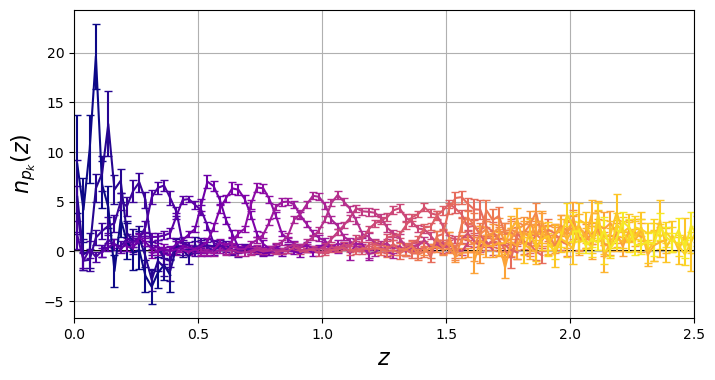

In [56]:
plt.figure(figsize=(8, 4))
for tomo in data.keys():
    z = np.array(data[tomo][0])
    nz = np.array(data[tomo][1])
    nz_errs = np.array(data[tomo][2])
    integ = np.trapezoid(nz, z)
    nz /= integ
    nz_errs /= integ
    mask = nz != 0
    plt.errorbar(
        z[mask],
        nz[mask],
        nz_errs[mask],
        capsize=3,
        color=cmap((int(tomo) - 1) / len(list(data.keys()))),
    )

plt.grid()
plt.axhline(0.0, color="black", zorder=1)
plt.xlim(0.0, 2.5)
plt.xlabel(r"$z$", fontsize=16)
plt.ylabel(r"$n_{p_k}(z)$", fontsize=16)

In [57]:
import importlib

importlib.reload(spline)
dz_phot = 0.1

for tomo in data.keys():
    outbase = save_splines / f"spline_tomo{tomo}"
    # only compute if it does not already exist, remove the following lines in case of overwrite
    if outbase.with_suffix(".nc").exists():
        continue

    z_center = int(tomo) * dz_phot - dz_phot / 2
    zv = np.array(data[tomo][0])
    npkz = np.array(data[tomo][1])
    npkz_errs = np.array(data[tomo][2])
    # remove the first measurement (bin 0).
    # setting error and value to 0 means the measurement is not 0,
    # but is ignored in the fit, since the error is null.
    npkz[0] = 0
    npkz_errs[0] = 0
    mask = (zv >= (z_center - 4 * dz_phot)) & (zv <= (z_center + 4 * dz_phot))
    zv_m = zv[mask]
    npkz_m = npkz[mask]
    npkz_errs_m = npkz_errs[mask]
    # renormalize a little bit for the base_alpha to make more sense,
    # though the actual value of base_alpha is not too sensitive to this normalization.
    # this is mostly to account for wdm amplitude, samples will be renormalized later on anyway.
    norm = np.trapezoid(npkz_m, zv_m)
    npkz_m /= norm
    npkz_errs_m /= norm

    spl = spline.BayesianBSpline(zv=np.array(zv_m), n_knots=len(np.array(zv_m)) // 2)
    spl.fit(
        np.array(npkz_m),
        np.array(npkz_errs_m),
        target_accept=0.99,
        n_samples=1250,
        n_tune=500,
        prior_concentration=3,
        base_alpha=0.05,
    )
    spl.save_model(filename_base=outbase)

In [58]:
## now register the n(z) distributions for every sample
tomo_dict = {}
for tomo in data.keys():
    spl = spline.BayesianBSpline.from_saved_model(
        filename_base=save_splines / f"spline_tomo{tomo}"
    )
    z_eval = np.linspace(0.0, 3.0, 500)
    results = spl.get_spline_from_trace(z_eval=z_eval)

    mask = (z_eval >= spl.zv.min()) & (z_eval <= spl.zv.max())
    redshifts = z_eval[mask]
    samples = spl.get_samples(z_eval=redshifts)
    # renormalize all samples
    nz_median = np.percentile(samples, 50, axis=0)
    nz_med_integ = np.trapezoid(nz_median, redshifts)
    nz_median_n = nz_median / nz_med_integ
    nz_lower_n = np.percentile(samples, 16, axis=0) / nz_med_integ
    nz_upper_n = np.percentile(samples, 84, axis=0) / nz_med_integ

    tomo_dict[tomo] = {
        "redshifts": redshifts,
        "nz_lower": nz_lower_n,
        "nz_upper": nz_upper_n,
        "nz_median": nz_median_n,
    }
tomo_dict_flattened = {
    f"{t}/{k}": v for t, d in tomo_dict.items() for k, v in d.items()
}
np.savez_compressed(save_splines / f"tomo_photoz.npz", **tomo_dict_flattened)

PyMC model recreated from parameters
Model loaded from:
  - Trace: results/photoz_bias_splines_0.3_3_vF/spline_tomo1.nc
  - Metadata: results/photoz_bias_splines_0.3_3_vF/spline_tomo1_meta.pkl
  - Posterior samples: 5000
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/photoz_bias_splines_0.3_3_vF/spline_tomo2.nc
  - Metadata: results/photoz_bias_splines_0.3_3_vF/spline_tomo2_meta.pkl
  - Posterior samples: 5000
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/photoz_bias_splines_0.3_3_vF/spline_tomo3.nc
  - Metadata: results/photoz_bias_splines_0.3_3_vF/spline_tomo3_meta.pkl
  - Posterior samples: 5000
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/photoz_bias_splines_0.3_3_vF/spline_tomo4.nc
  - Metadata: results/photoz_bias_splines_0.3_3_vF/spline_tomo4_meta.pkl
  - Posterior samples: 5000
PyMC model recreated from parameters
Model loaded from:
  - Trace: results/photoz_bias_splines_0.3_3_vF/spline_tomo5